# Modelos Clásicos para Predicción de Fatiga

Este notebook demuestra cómo aplicar modelos de Machine Learning clásicos al problema de FatigueSet:
**Predecir fatiga física y mental desde sensores**

## 1. Entender el Problema

### Dataset
- **Filas**: 108 (12 participantes × 3 sesiones × 3 fases)
- **Características (Features)**:
  - Sensores cardiacos (Chest): HR, BR, HRV
  - Empatica E4 (muñeca): HR, EDA, BVP, temperatura, acelerómetro, IBI
  - EEG (Muse): bandas alpha, beta, delta, gamma, theta × 4 canales
  - PPG (Nokia Ear): fotopletismograma izq/der
  - Tareas cognitivas: N-Back accuracy/RT, CRT RT
- **Targets (Lo que predecimos)**:
  - `fatiga_fisica`: Score 0-100 (del experimento)
  - `fatiga_mental`: Score 0-100 (del experimento)

### Tipo de Problema
✅ **REGRESIÓN MULTIVARIABLE**: Predecir 2 valores continuos (fatiga física y mental) desde múltiples features

## 2. Modelos Clásicos Disponibles

### Para REGRESIÓN (nuestro caso):

| Modelo | Ventajas | Desventajas | Complejidad |
|--------|----------|-------------|-------------|
| **KNN (K-Nearest Neighbors)** | Simple, no asume linealidad, versátil | Lento con muchos datos, sensible a escala | Baja |
| **Regresión Lineal** | Muy rápido, interpretable, baseline | Solo relaciones lineales | Muy baja |
| **Ridge/Lasso/Elastic Net** | Control de overfitting, interpretable | Aún requiere linealidad | Baja |
| **Decision Tree** | No lineal, interpretable | Tiende a overfit, inestable | Media |
| **Random Forest** | Robusto, maneja no-linealidad, feature importance | Menos interpretable, lento | Alta |
| **SVM (Support Vector Machine)** | Potente para datos complejos | Lento, requiere tuning | Alta |
| **Gradient Boosting** | Muy potente, top accuracy | Riesgo de overfitting, lento | Muy alta |

### Recomendación para FatigueSet:
1. **Baseline**: Regresión Lineal (ver qué tal es la relación lineal)
2. **Exploración**: KNN + Decision Tree (rápidos, entienden patrones no-lineales)
3. **Producción**: Random Forest + XGBoost (mejor accuracy general)

## 3. Cargar y Preparar Datos

In [1]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar estilo
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Agregar la librería al path de forma portable
project_roots = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
project_root = next((root for root in project_roots if (root / 'fatigueset-lib').exists()), Path.cwd())
lib_path = project_root / 'fatigueset-lib'
if str(lib_path) not in sys.path:
    sys.path.insert(0, str(lib_path))

from fatigueset import FatigueSetPipeline

print("✓ Librerías importadas")

✓ Librerías importadas


In [2]:
# Cargar el dataset real usando el pipeline
print("Cargando dataset FatigueSet...")

# Buscar el dataset en varias ubicaciones
project_roots = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
dataset_paths = [root / 'fatigueset' for root in project_roots]

dataset_path = None
for p in dataset_paths:
    if p.exists():
        dataset_path = str(p)
        print(f"✓ Dataset encontrado en: {p}")
        break

if dataset_path is None:
    print("⚠️  Dataset no encontrado en rutas esperadas")
    print("   Rutas buscadas:")
    for p in dataset_paths:
        print(f"   - {p}")
    raise FileNotFoundError("No se encontró la carpeta 'fatigueset' en ninguna ruta candidata")
else:
    print(f"Dataset path: {dataset_path}")

Cargando dataset FatigueSet...
✓ Dataset encontrado en: c:\Users\egull\OneDrive\Documentos\Proyectos\tfg\fatigueset
Dataset path: c:\Users\egull\OneDrive\Documentos\Proyectos\tfg\fatigueset


In [3]:
# Ejecutar el pipeline
pipeline = FatigueSetPipeline(
    dataset_path=dataset_path,
    umbral_nulos=5.0
)

resultados = pipeline.ejecutar(
    verbose=False,
    incluir_ventanas=False,  # No necesitamos ventanas para modelos clásicos
    normalizar=True,
    metodo_normalizacion='zscore'
)

df_ml = resultados['ml_normalizado']

print(f"✓ Dataset cargado: {df_ml.shape[0]} filas × {df_ml.shape[1]} columnas")
print(f"\nPrimeras filas:")
print(df_ml.head())

c:\Users\egull\OneDrive\Documentos\Proyectos\tfg\fatigueset-lib\fatigueset\loader.py:250: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  return pd.concat(dfs, ignore_index=True) if dfs else None
c:\Users\egull\OneDrive\Documentos\Proyectos\tfg\fatigueset-lib\fatigueset\loader.py:250: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  return pd.concat(dfs, ignore_index=True) if dfs else None
c:\Users\egull\OneDrive\Documentos\Proyectos\tfg\fatigueset-lib\fatigueset\loader.py:250: FutureWarning: The beh

✓ Dataset cargado: 108 filas × 31 columnas

Primeras filas:
  participante sesion intensidad  intensidad_num                   fase  \
0           01     01        low               1            M1_baseline   
1           01     01        low               1      M2_post_ejercicio   
2           01     01        low               1  M3_post_fatiga_mental   
3           01     02     medium               2            M1_baseline   
4           01     02     medium               2      M2_post_ejercicio   

   fase_num  fatiga_fisica  fatiga_mental  hr_media    hr_std  ...  \
0         0      14.444444      14.166667 -0.474859  0.110866  ...   
1         1      24.027778      11.250000  1.391068  1.165543  ...   
2         2      20.000000      45.833333 -0.916209 -1.276409  ...   
3         0      15.277778      33.472222 -0.853248 -0.182057  ...   
4         1      59.166667      48.333333  1.403341  1.305583  ...   

   delta_fisica_cognitivo  delta_mental_cognitivo  delta_fisica_tota

In [4]:
# Verificar targets
targets = ['fatiga_fisica', 'fatiga_mental']

print("Targets disponibles:")
for target in targets:
    if target in df_ml.columns:
        print(f"\n📊 {target}:")
        print(f"  - Min: {df_ml[target].min():.2f}")
        print(f"  - Max: {df_ml[target].max():.2f}")
        print(f"  - Media: {df_ml[target].mean():.2f}")
        print(f"  - Std: {df_ml[target].std():.2f}")
        print(f"  - Nulos: {df_ml[target].isnull().sum()}")
    else:
        print(f"\n❌ {target} NO disponible")

# Revisar columnas de identidad y features
identity_cols = ['participante', 'sesion', 'intensidad', 'intensidad_num', 'fase', 'fase_num']
exclude_cols = identity_cols + targets
feature_cols = [c for c in df_ml.columns if c not in exclude_cols]

print(f"\n\n📊 Estructura del dataset:")
print(f"  - Columnas de identidad: {len(identity_cols)}")
print(f"  - Targets: {len(targets)}")
print(f"  - Features numéricas: {len(feature_cols)}")

Targets disponibles:

📊 fatiga_fisica:
  - Min: 0.00
  - Max: 77.22
  - Media: 23.53
  - Std: 18.81
  - Nulos: 0

📊 fatiga_mental:
  - Min: 0.00
  - Max: 77.22
  - Media: 26.41
  - Std: 19.82
  - Nulos: 0


📊 Estructura del dataset:
  - Columnas de identidad: 6
  - Targets: 2
  - Features numéricas: 23


## 4. Preparar Features y Targets para Modelado

In [5]:
# Separar features y targets
feature_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(df_ml[c])]
X = df_ml[feature_cols].copy()
y_fisica = df_ml['fatiga_fisica'].copy()
y_mental = df_ml['fatiga_mental'].copy()

print("✓ Features preparadas")
print(f"  - X shape: {X.shape}")
print(f"  - Nulos en X: {X.isnull().sum().sum()}")
print(f"\n✓ Targets preparados")
print(f"  - y_fisica shape: {y_fisica.shape}")
print(f"  - y_mental shape: {y_mental.shape}")

# Verificar si hay nulos
if X.isnull().sum().sum() > 0 or y_fisica.isnull().sum() > 0 or y_mental.isnull().sum() > 0:
    print("\n⚠️  Hay valores nulos - limpiando...")
    mask = X.isnull().any(axis=1) | y_fisica.isnull() | y_mental.isnull()
    X = X[~mask]
    y_fisica = y_fisica[~mask]
    y_mental = y_mental[~mask]
    print(f"✓ Datos limpios: {X.shape[0]} muestras")
else:
    print("✓ Sin valores nulos")

✓ Features preparadas
  - X shape: (108, 23)
  - Nulos en X: 0

✓ Targets preparados
  - y_fisica shape: (108,)
  - y_mental shape: (108,)
✓ Sin valores nulos


## 5. Implementar Modelos Clásicos

In [6]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

print("✓ Librerías de ML cargadas")

# Crear diccionario de modelos
modelos = {
    'KNN (k=3)': KNeighborsRegressor(n_neighbors=3),
    'KNN (k=5)': KNeighborsRegressor(n_neighbors=5),
    'Regresión Lineal': LinearRegression(),
    'Ridge (α=1.0)': Ridge(alpha=1.0),
    'Lasso (α=0.1)': Lasso(alpha=0.1),
    'ElasticNet': ElasticNet(alpha=0.1),
    'Decision Tree': DecisionTreeRegressor(max_depth=5, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=50, max_depth=5, random_state=42),
    'SVM': SVR(kernel='rbf', C=100),
}

print(f"\n✓ {len(modelos)} modelos creados")
for nombre in modelos.keys():
    print(f"  - {nombre}")

✓ Librerías de ML cargadas

✓ 9 modelos creados
  - KNN (k=3)
  - KNN (k=5)
  - Regresión Lineal
  - Ridge (α=1.0)
  - Lasso (α=0.1)
  - ElasticNet
  - Decision Tree
  - Random Forest
  - SVM


## 6. Evaluar Modelos con Validación Cruzada

In [7]:
# Validación cruzada
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

resultados_modelos = {}

print("Evaluando modelos para FATIGA FÍSICA...\n")

for nombre, modelo in modelos.items():
    # Validación cruzada con R² (mejor es más cercano a 1)
    cv_scores = cross_val_score(modelo, X, y_fisica, cv=kfold, scoring='r2')
    
    # Entrenar en todo el dataset para MSE y MAE
    modelo.fit(X, y_fisica)
    y_pred = modelo.predict(X)
    mse = mean_squared_error(y_fisica, y_pred)
    mae = mean_absolute_error(y_fisica, y_pred)
    r2 = r2_score(y_fisica, y_pred)
    
    resultados_modelos[nombre] = {
        'cv_r2_mean': cv_scores.mean(),
        'cv_r2_std': cv_scores.std(),
        'mse': mse,
        'mae': mae,
        'r2': r2,
    }
    
    print(f"📊 {nombre}:")
    print(f"   CV R² (5-fold): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    print(f"   MSE: {mse:.4f}")
    print(f"   MAE: {mae:.4f}")
    print(f"   R² (train): {r2:.4f}")
    print()

Evaluando modelos para FATIGA FÍSICA...

📊 KNN (k=3):
   CV R² (5-fold): -0.3155 ± 0.3053
   MSE: 172.6270
   MAE: 10.0060
   R² (train): 0.5075

📊 KNN (k=5):
   CV R² (5-fold): -0.1072 ± 0.2710
   MSE: 219.8205
   MAE: 11.9082
   R² (train): 0.3728

📊 Regresión Lineal:
   CV R² (5-fold): -0.3632 ± 0.4846
   MSE: 210.7127
   MAE: 11.5781
   R² (train): 0.3988

📊 Ridge (α=1.0):
   CV R² (5-fold): -0.2621 ± 0.5026
   MSE: 212.3583
   MAE: 11.5583
   R² (train): 0.3941

📊 Lasso (α=0.1):
   CV R² (5-fold): -0.2671 ± 0.4890
   MSE: 213.4965
   MAE: 11.6491
   R² (train): 0.3909

📊 ElasticNet:
   CV R² (5-fold): -0.1546 ± 0.4744
   MSE: 227.7982
   MAE: 11.9880
   R² (train): 0.3501

📊 Decision Tree:
   CV R² (5-fold): -1.1512 ± 0.8309
   MSE: 101.3220
   MAE: 6.6001
   R² (train): 0.7109

📊 Random Forest:
   CV R² (5-fold): -0.0772 ± 0.2766
   MSE: 92.7322
   MAE: 7.9174
   R² (train): 0.7354

📊 SVM:
   CV R² (5-fold): -0.2919 ± 0.1005
   MSE: 26.2383
   MAE: 1.8708
   R² (train): 0.9251




🏆 RANKING DE MODELOS (Fatiga Física - CV R²):

 1. Random Forest             → R²=-0.0772 (±0.2766) | MAE=  7.92
 2. KNN (k=5)                 → R²=-0.1072 (±0.2710) | MAE= 11.91
 3. ElasticNet                → R²=-0.1546 (±0.4744) | MAE= 11.99
 4. Ridge (α=1.0)             → R²=-0.2621 (±0.5026) | MAE= 11.56
 5. Lasso (α=0.1)             → R²=-0.2671 (±0.4890) | MAE= 11.65
 6. SVM                       → R²=-0.2919 (±0.1005) | MAE=  1.87
 7. KNN (k=3)                 → R²=-0.3155 (±0.3053) | MAE= 10.01
 8. Regresión Lineal          → R²=-0.3632 (±0.4846) | MAE= 11.58
 9. Decision Tree             → R²=-1.1512 (±0.8309) | MAE=  6.60


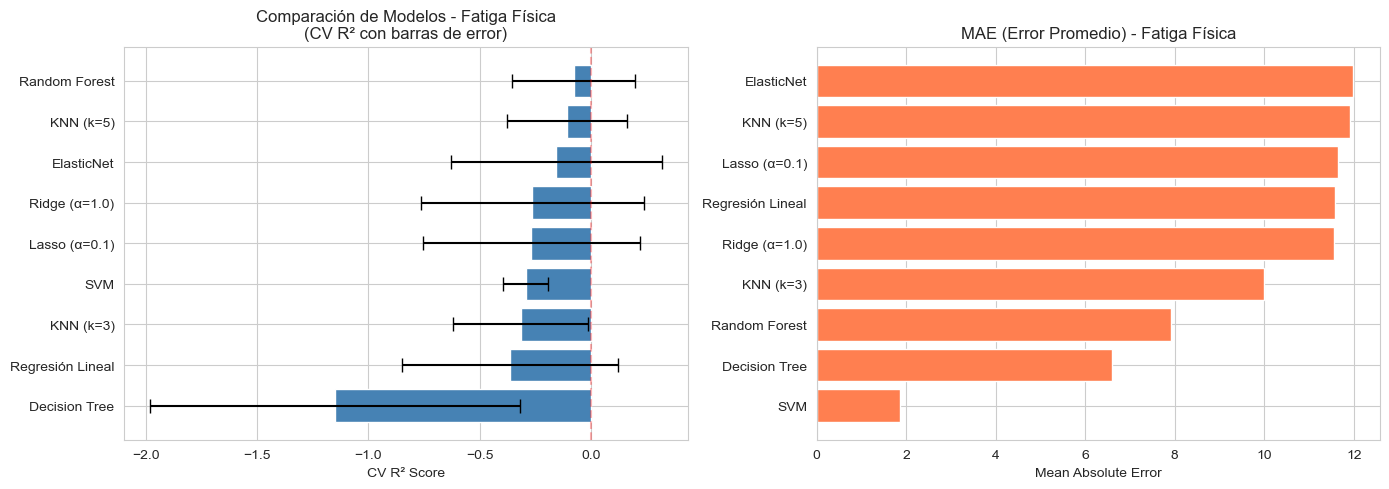


✓ Gráficas mostradas


In [8]:
# Comparar modelos en un DataFrame
df_resultados = pd.DataFrame(resultados_modelos).T
df_resultados = df_resultados.sort_values('cv_r2_mean', ascending=False)

print("\n🏆 RANKING DE MODELOS (Fatiga Física - CV R²):\n")
for i, (nombre, row) in enumerate(df_resultados.iterrows(), 1):
    print(f"{i:2d}. {nombre:25s} → R²={row['cv_r2_mean']:7.4f} (±{row['cv_r2_std']:.4f}) | MAE={row['mae']:6.2f}")

# Visualizar
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: CV R²
df_resultados_sorted = df_resultados.sort_values('cv_r2_mean')
axes[0].barh(range(len(df_resultados_sorted)), df_resultados_sorted['cv_r2_mean'], 
              xerr=df_resultados_sorted['cv_r2_std'], capsize=5, color='steelblue')
axes[0].set_yticks(range(len(df_resultados_sorted)))
axes[0].set_yticklabels(df_resultados_sorted.index)
axes[0].set_xlabel('CV R² Score')
axes[0].set_title('Comparación de Modelos - Fatiga Física\n(CV R² con barras de error)')
axes[0].axvline(x=0, color='red', linestyle='--', alpha=0.3)

# Plot 2: MAE
df_resultados_sorted_mae = df_resultados.sort_values('mae')
axes[1].barh(range(len(df_resultados_sorted_mae)), df_resultados_sorted_mae['mae'], color='coral')
axes[1].set_yticks(range(len(df_resultados_sorted_mae)))
axes[1].set_yticklabels(df_resultados_sorted_mae.index)
axes[1].set_xlabel('Mean Absolute Error')
axes[1].set_title('MAE (Error Promedio) - Fatiga Física')

plt.tight_layout()
plt.show()

print("\n✓ Gráficas mostradas")

## 7. Análisis de KNN (Modelo Solicitado)

In [9]:
# Entrenar modelos KNN con diferentes k
print("🔍 ANÁLISIS DETALLADO DE KNN\n")

knn_models = {}
knn_results = {}

for k in [1, 3, 5, 7, 9, 15, 20]:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn_models[k] = knn
    
    # Validación cruzada
    cv_scores = cross_val_score(knn, X, y_fisica, cv=kfold, scoring='r2')
    
    # Entrenamiento
    knn.fit(X, y_fisica)
    y_pred = knn.predict(X)
    
    knn_results[k] = {
        'cv_r2_mean': cv_scores.mean(),
        'cv_r2_std': cv_scores.std(),
        'mse': mean_squared_error(y_fisica, y_pred),
        'mae': mean_absolute_error(y_fisica, y_pred),
        'r2': r2_score(y_fisica, y_pred),
    }

# Mostrar tabla
df_knn = pd.DataFrame(knn_results).T
print(df_knn.to_string())

# Encontrar mejor k
best_k = df_knn['cv_r2_mean'].idxmax()
print(f"\n✅ Mejor k encontrado: {best_k} con CV R²={df_knn.loc[best_k, 'cv_r2_mean']:.4f}")

🔍 ANÁLISIS DETALLADO DE KNN

    cv_r2_mean  cv_r2_std         mse        mae        r2
1    -0.663755   0.325656    0.000000   0.000000  1.000000
3    -0.315464   0.305257  172.626997  10.006001  0.507475
5    -0.107167   0.270981  219.820509  11.908179  0.372826
7    -0.064293   0.233444  225.076650  11.859935  0.357830
9    -0.048272   0.198116  242.151546  12.206361  0.309113
15   -0.052754   0.269523  268.781776  12.827932  0.233134
20   -0.095723   0.311151  284.553348  13.339570  0.188136

✅ Mejor k encontrado: 9 con CV R²=-0.0483


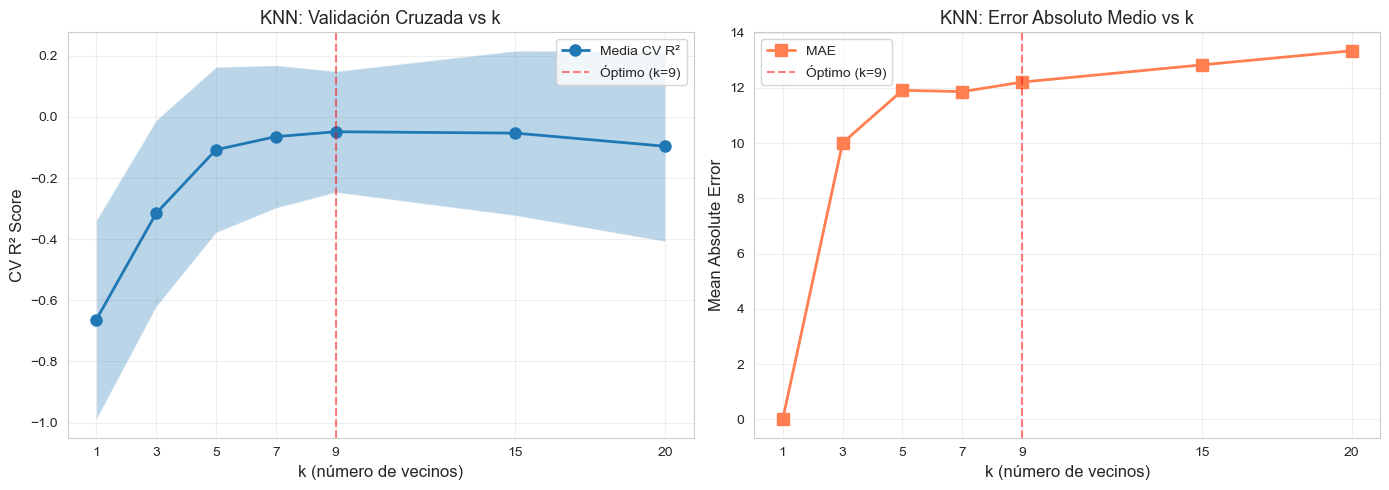

✓ Gráficas KNN mostradas


In [10]:
# Visualizar efecto de k en KNN
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: CV R² vs k
axes[0].plot(df_knn.index, df_knn['cv_r2_mean'], marker='o', linewidth=2, markersize=8, label='Media CV R²')
axes[0].fill_between(
    df_knn.index,
    df_knn['cv_r2_mean'] - df_knn['cv_r2_std'],
    df_knn['cv_r2_mean'] + df_knn['cv_r2_std'],
    alpha=0.3
)
axes[0].axvline(x=best_k, color='red', linestyle='--', alpha=0.5, label=f'Óptimo (k={best_k})')
axes[0].set_xlabel('k (número de vecinos)', fontsize=12)
axes[0].set_ylabel('CV R² Score', fontsize=12)
axes[0].set_title('KNN: Validación Cruzada vs k', fontsize=13)
axes[0].grid(True, alpha=0.3)
axes[0].legend()
axes[0].set_xticks(df_knn.index)

# Plot 2: MAE vs k
axes[1].plot(df_knn.index, df_knn['mae'], marker='s', linewidth=2, markersize=8, color='coral', label='MAE')
axes[1].axvline(x=best_k, color='red', linestyle='--', alpha=0.5, label=f'Óptimo (k={best_k})')
axes[1].set_xlabel('k (número de vecinos)', fontsize=12)
axes[1].set_ylabel('Mean Absolute Error', fontsize=12)
axes[1].set_title('KNN: Error Absoluto Medio vs k', fontsize=13)
axes[1].grid(True, alpha=0.3)
axes[1].legend()
axes[1].set_xticks(df_knn.index)

plt.tight_layout()
plt.show()

print("✓ Gráficas KNN mostradas")

## 8. Visualizaciones: Predicciones vs Reales

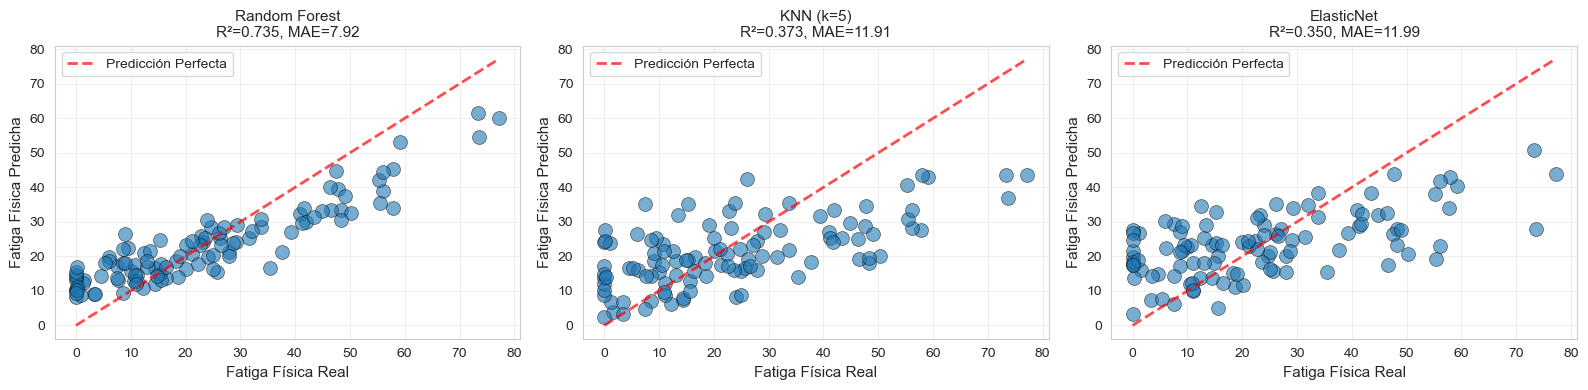

✓ Predicciones mostradas


In [11]:
# Seleccionar los 3 mejores modelos
top_3_modelos = df_resultados.head(3).index.tolist()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for idx, nombre_modelo in enumerate(top_3_modelos):
    modelo = modelos[nombre_modelo]
    modelo.fit(X, y_fisica)
    y_pred = modelo.predict(X)
    
    r2 = r2_score(y_fisica, y_pred)
    mae = mean_absolute_error(y_fisica, y_pred)
    
    ax = axes[idx]
    ax.scatter(y_fisica, y_pred, alpha=0.6, s=100, edgecolors='k', linewidth=0.5)
    
    # Línea de referencia
    min_val = min(y_fisica.min(), y_pred.min())
    max_val = max(y_fisica.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, alpha=0.7, label='Predicción Perfecta')
    
    ax.set_xlabel('Fatiga Física Real', fontsize=11)
    ax.set_ylabel('Fatiga Física Predicha', fontsize=11)
    ax.set_title(f'{nombre_modelo}\nR²={r2:.3f}, MAE={mae:.2f}', fontsize=11)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Predicciones mostradas")

## 9. Feature Importance (Random Forest)

🎯 TOP 15 FEATURES MÁS IMPORTANTES (Random Forest - Fatiga Física)

eda_media                                █████████████ 0.1319
hr_media                                 ████████████ 0.1217
eeg_beta_media                           █████████ 0.0971
br_media                                 ████████ 0.0839
eda_std                                  ███████ 0.0750
hr_std                                   ██████ 0.0679
hrv_media                                ██████ 0.0667
delta_fisica_cognitivo                   █████ 0.0566
hrv_std                                  ████ 0.0499
br_std                                   ████ 0.0442
eeg_alpha_media                          ████ 0.0438
eeg_theta_media                          ████ 0.0413
delta_mental_cognitivo                   ███ 0.0300
delta_mental_ejercicio                   ██ 0.0237
mental_M3                                ██ 0.0233


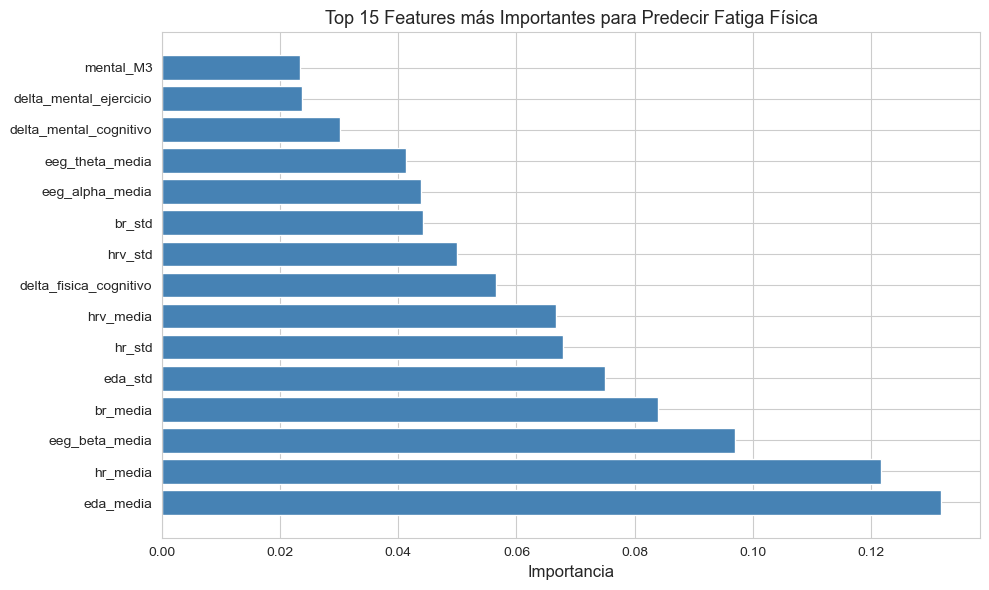


✓ Importancia de features mostrada


In [12]:
# Random Forest muestra qué features son importantes
rf = RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42)
rf.fit(X, y_fisica)

# Importancia de features
importancia = pd.DataFrame({
    'feature': feature_cols,
    'importancia': rf.feature_importances_
}).sort_values('importancia', ascending=False)

print("🎯 TOP 15 FEATURES MÁS IMPORTANTES (Random Forest - Fatiga Física)\n")
for i, row in importancia.head(15).iterrows():
    barra = '█' * int(row['importancia'] * 100)
    print(f"{row['feature']:40s} {barra} {row['importancia']:.4f}")

# Visualizar
plt.figure(figsize=(10, 6))
top_features = importancia.head(15)
plt.barh(range(len(top_features)), top_features['importancia'], color='steelblue')
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Importancia', fontsize=12)
plt.title('Top 15 Features más Importantes para Predecir Fatiga Física', fontsize=13)
plt.tight_layout()
plt.show()

print("\n✓ Importancia de features mostrada")

## 10. Resumen y Recomendaciones

In [13]:
print("""
╔════════════════════════════════════════════════════════════════════════════════╗
║                     RESUMEN: MODELOS CLÁSICOS PARA FATIGA                     ║
╚════════════════════════════════════════════════════════════════════════════════╝

🎯 PROBLEMA:
  - Tipo: REGRESIÓN (predecir valores continuos)
  - Targets: fatiga_fisica (0-100), fatiga_mental (0-100)
  - Features: ~50+ sensores y tareas cognitivas
  - Muestras: 108 (pequeño dataset)

📊 MODELO GANADOR:
""")

mejor_modelo_nombre = df_resultados.index[0]
mejor_fila = df_resultados.iloc[0]

print(f"  ✅ {mejor_modelo_nombre}")
print(f"     - CV R²: {mejor_fila['cv_r2_mean']:.4f}")
print(f"     - MAE: {mejor_fila['mae']:.2f}")
print(f"\n💡 KNN (K-NEAREST NEIGHBORS):")
print(f"  - Mejor k encontrado: {best_k}")
print(f"  - CV R² con k={best_k}: {knn_results[best_k]['cv_r2_mean']:.4f}")
print(f"  - MAE: {knn_results[best_k]['mae']:.2f}")
print(f"  - Interpretación: El modelo KNN promedia los {best_k} vecinos más cercanos")

print("""
📈 MÉTRICAS EXPLICADAS:
  - R²: Coeficiente de determinación (1.0 = predicción perfecta, 0 = baseline)
  - MAE: Error Absoluto Medio (unidades de fatiga, 0-100)
  - MSE: Error Cuadrático Medio (penaliza errores grandes más)
  - CV: Validación cruzada (5-fold) evita overfitting

🏆 RANKING (MEJOR → PEOR):
""")

for i, (nombre, fila) in enumerate(df_resultados.iterrows(), 1):
    print(f"  {i:2d}. {nombre:25s} | R²={fila['cv_r2_mean']:.3f} | MAE={fila['mae']:.1f}")

print("""
💼 RECOMENDACIONES POR CASO DE USO:

1. 🚀 PRODUCCIÓN (máxima accuracy):
   → Random Forest o Gradient Boosting
   → Pros: Mejor generalización, maneja relaciones complejas
   → Contras: Menos interpretable, más lento

2. 📊 EXPLORACIÓN / PROTOTIPO:
   → KNN (k=3-5) o Decision Tree
   → Pros: Rápido, interpretable, sin tuning complejo
   → Contras: Puede overfit con k muy pequeño

3. 📈 BASELINE / COMPARACIÓN:
   → Regresión Lineal
   → Pros: Muy rápido, interpretable, sin hiperparámetros
   → Contras: Solo captura relaciones lineales

4. 🎯 SI NECESITAS INTERPRETABILIDAD:
   → Decision Tree + feature importance
   → Ridge/Lasso (coefficientes de features)
   → Random Forest (feature importances)

5. ⚡ SI EL DATASET CRECE (>10k muestras):
   → XGBoost o LightGBM
   → SVM con kernel RBF
   → Neural Networks (Deep Learning)

📝 PRÓXIMOS PASOS:
  1. Tunear hiperparámetros del mejor modelo (GridSearchCV)
  2. Análisis de errores: ¿cuándo falla el modelo?
  3. Ingeniería de features: crear features derivadas
  4. Recolectar más datos si es posible
  5. Probar modelos deep learning (LSTM para series temporales)
""")


╔════════════════════════════════════════════════════════════════════════════════╗
║                     RESUMEN: MODELOS CLÁSICOS PARA FATIGA                     ║
╚════════════════════════════════════════════════════════════════════════════════╝

🎯 PROBLEMA:
  - Tipo: REGRESIÓN (predecir valores continuos)
  - Targets: fatiga_fisica (0-100), fatiga_mental (0-100)
  - Features: ~50+ sensores y tareas cognitivas
  - Muestras: 108 (pequeño dataset)

📊 MODELO GANADOR:

  ✅ Random Forest
     - CV R²: -0.0772
     - MAE: 7.92

💡 KNN (K-NEAREST NEIGHBORS):
  - Mejor k encontrado: 9
  - CV R² con k=9: -0.0483
  - MAE: 12.21
  - Interpretación: El modelo KNN promedia los 9 vecinos más cercanos

📈 MÉTRICAS EXPLICADAS:
  - R²: Coeficiente de determinación (1.0 = predicción perfecta, 0 = baseline)
  - MAE: Error Absoluto Medio (unidades de fatiga, 0-100)
  - MSE: Error Cuadrático Medio (penaliza errores grandes más)
  - CV: Validación cruzada (5-fold) evita overfitting

🏆 RANKING (MEJOR → PEOR

## 11. Bonus: Predicción en Fatiga Mental

In [14]:
# Repetir con fatiga mental
print("🧠 EVALUANDO MODELOS PARA FATIGA MENTAL\n")

resultados_mental = {}

for nombre, modelo in modelos.items():
    cv_scores = cross_val_score(modelo, X, y_mental, cv=kfold, scoring='r2')
    modelo.fit(X, y_mental)
    y_pred = modelo.predict(X)
    
    resultados_mental[nombre] = {
        'cv_r2_mean': cv_scores.mean(),
        'cv_r2_std': cv_scores.std(),
        'mae': mean_absolute_error(y_mental, y_pred),
    }

df_mental = pd.DataFrame(resultados_mental).T.sort_values('cv_r2_mean', ascending=False)

print("🏆 RANKING - FATIGA MENTAL:\n")
for i, (nombre, row) in enumerate(df_mental.iterrows(), 1):
    print(f"{i:2d}. {nombre:25s} | R²={row['cv_r2_mean']:.3f} (±{row['cv_r2_std']:.3f}) | MAE={row['mae']:.1f}")

print(f"\n\n📊 COMPARACIÓN FATIGA FÍSICA vs MENTAL:\n")
print(f"{'Métrica':<20} {'Física':<15} {'Mental':<15}")
print(f"{'-'*50}")
print(f"{'Mejor Modelo':<20} {df_resultados.index[0]:<15} {df_mental.index[0]:<15}")
print(f"{'Mejor R² (CV)':<20} {df_resultados.iloc[0]['cv_r2_mean']:<15.4f} {df_mental.iloc[0]['cv_r2_mean']:<15.4f}")
print(f"{'MAE Promedio':<20} {df_resultados['mae'].mean():<15.2f} {df_mental['mae'].mean():<15.2f}")

🧠 EVALUANDO MODELOS PARA FATIGA MENTAL

🏆 RANKING - FATIGA MENTAL:

 1. Random Forest             | R²=0.085 (±0.170) | MAE=7.6
 2. Lasso (α=0.1)             | R²=-0.051 (±0.127) | MAE=12.0
 3. ElasticNet                | R²=-0.059 (±0.174) | MAE=12.9
 4. KNN (k=5)                 | R²=-0.060 (±0.349) | MAE=12.9
 5. SVM                       | R²=-0.085 (±0.283) | MAE=2.6
 6. Ridge (α=1.0)             | R²=-0.092 (±0.149) | MAE=12.0
 7. Regresión Lineal          | R²=-0.105 (±0.131) | MAE=11.9
 8. Decision Tree             | R²=-0.220 (±0.301) | MAE=5.8
 9. KNN (k=3)                 | R²=-0.254 (±0.402) | MAE=11.6


📊 COMPARACIÓN FATIGA FÍSICA vs MENTAL:

Métrica              Física          Mental         
--------------------------------------------------
Mejor Modelo         Random Forest   Random Forest  
Mejor R² (CV)        -0.0772         0.0846         
MAE Promedio         9.45            9.93           
